In [1]:
import numpy as np
import pandas as pd
from scapy.all import rdpcap, raw
import matplotlib.pyplot as pl
import seaborn as sns



In [2]:
import numpy as np
import os
import gc
import pywt


In [3]:
# def dwt_3wavelet_single(img):
#     LL1, _ = pywt.dwt2(img, 'coif1')
#     LL2, _ = pywt.dwt2(img, 'db3')
#     LL3, _ = pywt.dwt2(img, 'rbio1.3')

#     # 🔴 POTONG KE 32×32
#     LL1 = LL1[:128, :128]
#     LL2 = LL2[:128, :128]
#     LL3 = LL3[:128, :128]

#     return np.stack([LL1, LL2, LL3], axis=-1)


def dwt_3wavelet_single(img, level, input_size):

    coif = img.copy()
    db3  = img.copy()
    rbio = img.copy()

    for _ in range(level):
        coif, _ = pywt.dwt2(coif, 'coif1')
        db3, _  = pywt.dwt2(db3, 'db3')
        rbio, _ = pywt.dwt2(rbio, 'rbio1.3')

    # safeguard ukuran
    target_size = input_size // (2 ** level)

    coif = coif[:target_size, :target_size]
    db3  = db3[:target_size, :target_size]
    rbio = rbio[:target_size, :target_size]

    return np.stack([coif, db3, rbio], axis=-1)

Fokus Train

In [4]:
import os
import numpy as np
Loader = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize128lv3/norm/"
# Save directory lv4
SAVE_DIR = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize128lv4/norm/dwt"

SAVE_DIR2 = "/home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize128lv4/norm/dwt/sample/"
# =========================
# Buat folder jika belum ada
# =========================
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(SAVE_DIR2, exist_ok=True)
train_path = os.path.join(Loader, "tow_ids_train_windows_norm.npz")
eval_path = os.path.join(Loader, "tow_ids_eval_windows_norm.npz")
# load
train_data = np.load(train_path)
eval_data = np.load(eval_path)

X = train_data["X"]
y = train_data["y"]
X_eval = eval_data["X"]
y_eval = eval_data["y"]



In [5]:
print("X shape :", X.shape)
print("X dtype :", X.dtype)

print("y shape :", y.shape)
print("y dtype :", y.dtype)

print("X_eval shape :", X_eval.shape)
print("X_eval dtype :", X_eval.dtype)

print("y_eval shape :", y_eval.shape)
print("y_eval dtype :", y_eval.dtype)

X shape : (6582, 128, 128)
X dtype : float32
y shape : (6582,)
y dtype : int64
X_eval shape : (2821, 128, 128)
X_eval dtype : float32
y_eval shape : (2821,)
y_eval dtype : int64


In [6]:
level = 4
input_size = 128
target_size = input_size // (2 ** level)

N = X.shape[0]

X_dwt = np.empty(
    (N, target_size, target_size, 3),
    dtype=np.float32
)

for i in range(N):
    X_dwt[i] = dwt_3wavelet_single(X[i], level=level, input_size=input_size)

print("DWT Done:")
print("Shape:", X_dwt.shape)

DWT Done:
Shape: (6582, 8, 8, 3)


In [7]:


N = X_eval.shape[0]

X_eval_dwt = np.empty(
    (N, target_size, target_size, 3),
    dtype=np.float32
)

for i in range(N):
    X_eval_dwt[i] = dwt_3wavelet_single(X_eval[i], level=level, input_size=input_size)

print("DWT Done:")
print("Shape:", X_eval_dwt.shape)

DWT Done:
Shape: (2821, 8, 8, 3)


In [8]:
print("\n=== Statistik DWT ===")
print("Min :", X_dwt.min())
print("Max :", X_dwt.max())
print("Mean:", X_dwt.mean())
print("Shape:", X_dwt.shape)
print("Mean per channel:", X_dwt.mean(axis=(0,1,2)))
print("Std per channel :", X_dwt.std(axis=(0,1,2)))


print("\n=== Statistik DWT eval ===")
print("Min :", X_eval_dwt.min())
print("Max :", X_eval_dwt.max())
print("Mean:", X_eval_dwt.mean())
print("Shape:", X_eval_dwt.shape)
print("Mean per channel:", X_eval_dwt.mean(axis=(0,1,2)))
print("Std per channel :", X_eval_dwt.std(axis=(0,1,2)))


=== Statistik DWT ===
Min : -1.591844
Max : 14.266565
Mean: 5.7019095
Shape: (6582, 8, 8, 3)
Mean per channel: [5.576307 5.998207 5.532056]
Std per channel : [3.6091259 2.8399503 4.2035565]

=== Statistik DWT eval ===
Min : -1.220237
Max : 15.999998
Mean: 5.365017
Shape: (2821, 8, 8, 3)
Mean per channel: [5.265048  5.6671677 5.162117 ]
Std per channel : [3.3140123 2.63273   3.8288743]


In [9]:
import matplotlib.pyplot as plt
np.random.seed(42)
indices = np.random.choice(len(X_dwt), 5, replace=False)

for idx in indices:
    img = X_dwt[idx]
    label = y[idx]

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")

    img_path = os.path.join(SAVE_DIR2, f"sample_{idx}_label_{label}_normalized train.png")
    plt.savefig(img_path, bbox_inches="tight", pad_inches=0)
    plt.close()

print("Saved 5 sample images.")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.331438..12.109802].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.11039175..12.235293].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7220507..12.109802].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.116658375..12.10588].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.67810726..12.109802].


Saved 5 sample images.


In [10]:
np.random.seed(42)
indices = np.random.choice(len(X_eval_dwt), 5, replace=False)

for idx in indices:
    img = X_eval_dwt[idx]
    label = y_eval[idx]
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")

    img_path = os.path.join(SAVE_DIR2, f"sample_{idx}_label_{label}_normalized val.png")
    plt.savefig(img_path, bbox_inches="tight", pad_inches=0)
    plt.close()

print("Saved 5 sample images.")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.50180465..12.325489].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1519451..11.050979].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.552053..12.109802].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7924829..12.109802].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.43743733..11.547057].


Saved 5 sample images.


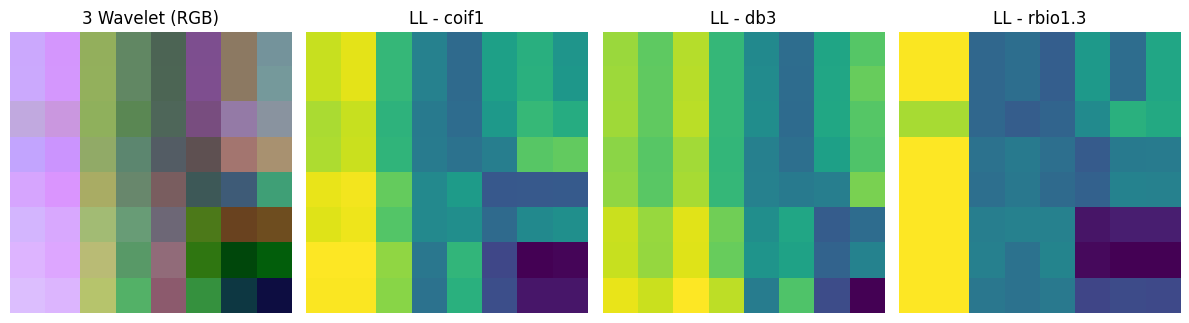

In [11]:
# ambil 1 sample untuk demo
demo_idx = 0
demo_img = X_dwt[demo_idx]

# scaling agar visual bagus
demo_vis = demo_img.copy()
demo_vis = (demo_vis - demo_vis.min()) / (demo_vis.max() - demo_vis.min() + 1e-8)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(demo_vis)
plt.title("3 Wavelet (RGB)")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(demo_vis[:,:,0], cmap="viridis")
plt.title("LL - coif1")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(demo_vis[:,:,1], cmap="viridis")
plt.title("LL - db3")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(demo_vis[:,:,2], cmap="viridis")
plt.title("LL - rbio1.3")
plt.axis("off")

plt.tight_layout()
plt.show()

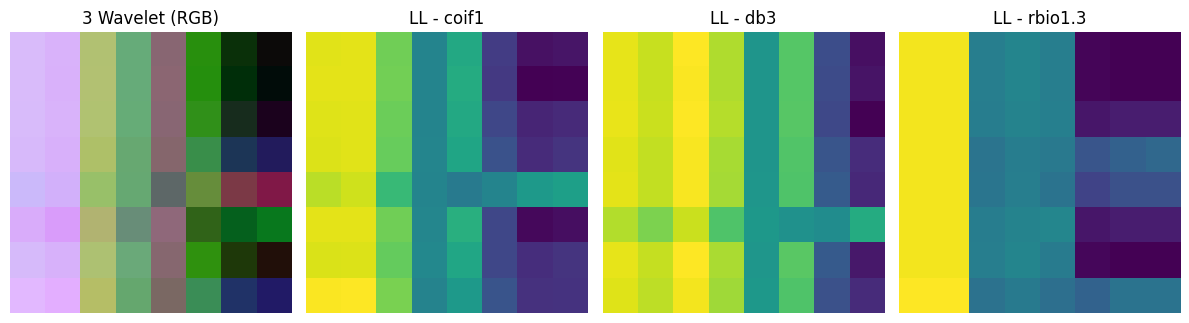

In [12]:
# ambil 1 sample untuk demo
demo_idx = 0
demo_img = X_eval_dwt[demo_idx]

# scaling agar visual bagus
demo_vis = demo_img.copy()
demo_vis = (demo_vis - demo_vis.min()) / (demo_vis.max() - demo_vis.min() + 1e-8)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(demo_vis)
plt.title("3 Wavelet (RGB)")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(demo_vis[:,:,0], cmap="viridis")
plt.title("LL - coif1")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(demo_vis[:,:,1], cmap="viridis")
plt.title("LL - db3")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(demo_vis[:,:,2], cmap="viridis")
plt.title("LL - rbio1.3")
plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
print("Channel variance:")
print("coif1:", np.var(X_dwt[:,:, :,0]))
print("db3  :", np.var(X_dwt[:,:, :,1]))
print("rbio :", np.var(X_dwt[:,:, :,2]))


print("Channel variance:")
print("coif1:", np.var(X_eval_dwt[:,:, :,0]))
print("db3  :", np.var(X_eval_dwt[:,:, :,1]))
print("rbio :", np.var(X_eval_dwt[:,:, :,2]))

Channel variance:
coif1: 13.027709
db3  : 8.065792
rbio : 17.679005
Channel variance:
coif1: 10.982682
db3  : 6.9314094
rbio : 14.65989


In [14]:
print(X_dwt.shape)
print(X_dwt.min(), X_dwt.max())

(6582, 8, 8, 3)
-1.591844 14.266565


In [15]:
print(X_eval_dwt.shape)
print(X_eval_dwt.min(), X_eval_dwt.max())

(2821, 8, 8, 3)
-1.220237 15.999998


In [16]:
OUT_NPZ = os.path.join(SAVE_DIR, "tow_ids_train_dwt.npz")
np.savez(OUT_NPZ, X=X_dwt, y=y)

print("Saved NPZ:", OUT_NPZ)

Saved NPZ: /home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize128lv4/norm/dwt/tow_ids_train_dwt.npz


In [17]:
OUT_NPZ = os.path.join(SAVE_DIR, "tow_ids_eval_dwt.npz")
np.savez(OUT_NPZ, X=X_eval_dwt, y=y_eval)

print("Saved NPZ:", OUT_NPZ)

Saved NPZ: /home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize128lv4/norm/dwt/tow_ids_eval_dwt.npz


In [18]:
del X, y, X_dwt, X_eval_dwt, y_eval
gc.collect()

print("Memory cleaned.")

Memory cleaned.


Fokus ke Test

In [19]:
import os
import numpy as np
test_path = os.path.join(Loader, "tow_ids_test_windows_norm.npz")
# load
test_data = np.load(test_path)

X = test_data["X"]
y = test_data["y"]



In [20]:
print("X shape :", X.shape)
print("X dtype :", X.dtype)

print("y shape :", y.shape)
print("y dtype :", y.dtype)

X shape : (6184, 128, 128)
X dtype : float32
y shape : (6184,)
y dtype : int64


In [21]:


N = X.shape[0]

X_dwt = np.empty(
    (N, target_size, target_size, 3),
    dtype=np.float32
)

for i in range(N):
    X_dwt[i] = dwt_3wavelet_single(X[i], level=level, input_size=input_size)

print("DWT Done:")
print("Shape:", X_dwt.shape)

DWT Done:
Shape: (6184, 8, 8, 3)


In [22]:
print("\n=== Statistik DWT ===")
print("Min :", X_dwt.min())
print("Max :", X_dwt.max())
print("Mean:", X_dwt.mean())
print("Shape:", X_dwt.shape)


=== Statistik DWT ===
Min : -1.2955683
Max : 14.255652
Mean: 5.6829376
Shape: (6184, 8, 8, 3)


In [23]:
OUT_NPZ = os.path.join(SAVE_DIR, "tow_ids_test_dwt.npz")
np.savez(OUT_NPZ, X=X_dwt, y=y)

print("Saved NPZ:", OUT_NPZ)

Saved NPZ: /home/dani/Documents/tugas akhir/TugasAkhir/codeTugasAkhirku2026/tow_ids/Preprocessing/Preprocessingbaru/imgsize128lv4/norm/dwt/tow_ids_test_dwt.npz


In [24]:
np.random.seed(42)
indices = np.random.choice(N, 5, replace=False)

for idx in indices:
    img = X_dwt[idx]
    label = y[idx]

    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Label: {label}")
    plt.axis("off")

    img_path = os.path.join(SAVE_DIR2, f"sample_{idx}_label_{label}_normalizedtest.png")
    plt.savefig(img_path, bbox_inches="tight", pad_inches=0)
    plt.close()

print("Saved 5 sample images.")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.64203477..12.109802].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0968994..13.333331].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.26149148..12.109802].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.15324923..10.574509].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.047932588..12.10588].


Saved 5 sample images.


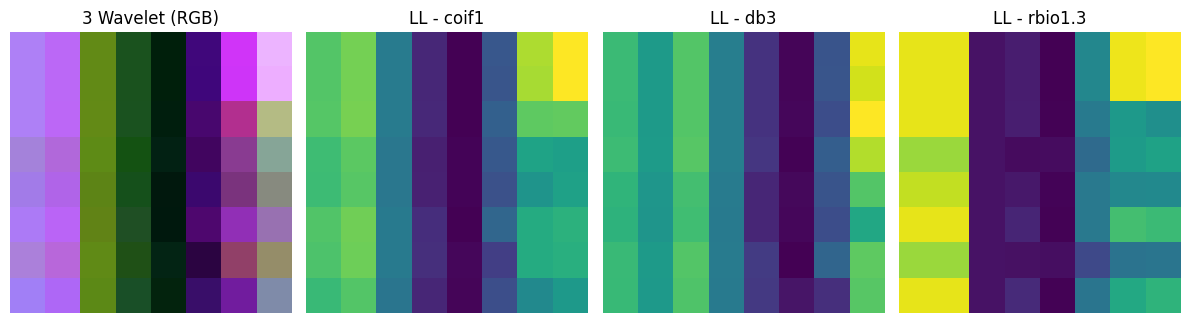

In [25]:
# ambil 1 sample untuk demo
demo_idx = 0
demo_img = X_dwt[demo_idx]

# scaling agar visual bagus
demo_vis = demo_img.copy()
demo_vis = (demo_vis - demo_vis.min()) / (demo_vis.max() - demo_vis.min() + 1e-8)

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(demo_vis)
plt.title("3 Wavelet (RGB)")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(demo_vis[:,:,0], cmap="viridis")
plt.title("LL - coif1")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(demo_vis[:,:,1], cmap="viridis")
plt.title("LL - db3")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(demo_vis[:,:,2], cmap="viridis")
plt.title("LL - rbio1.3")
plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
print("Channel variance:")
print("coif1:", np.var(X_dwt[:,:, :,0]))
print("db3  :", np.var(X_dwt[:,:, :,1]))
print("rbio :", np.var(X_dwt[:,:, :,2]))


Channel variance:
coif1: 12.4161215
db3  : 7.6584854
rbio : 16.995718


In [27]:
del X, y, X_dwt
gc.collect()

print("Memory cleaned.")

Memory cleaned.
